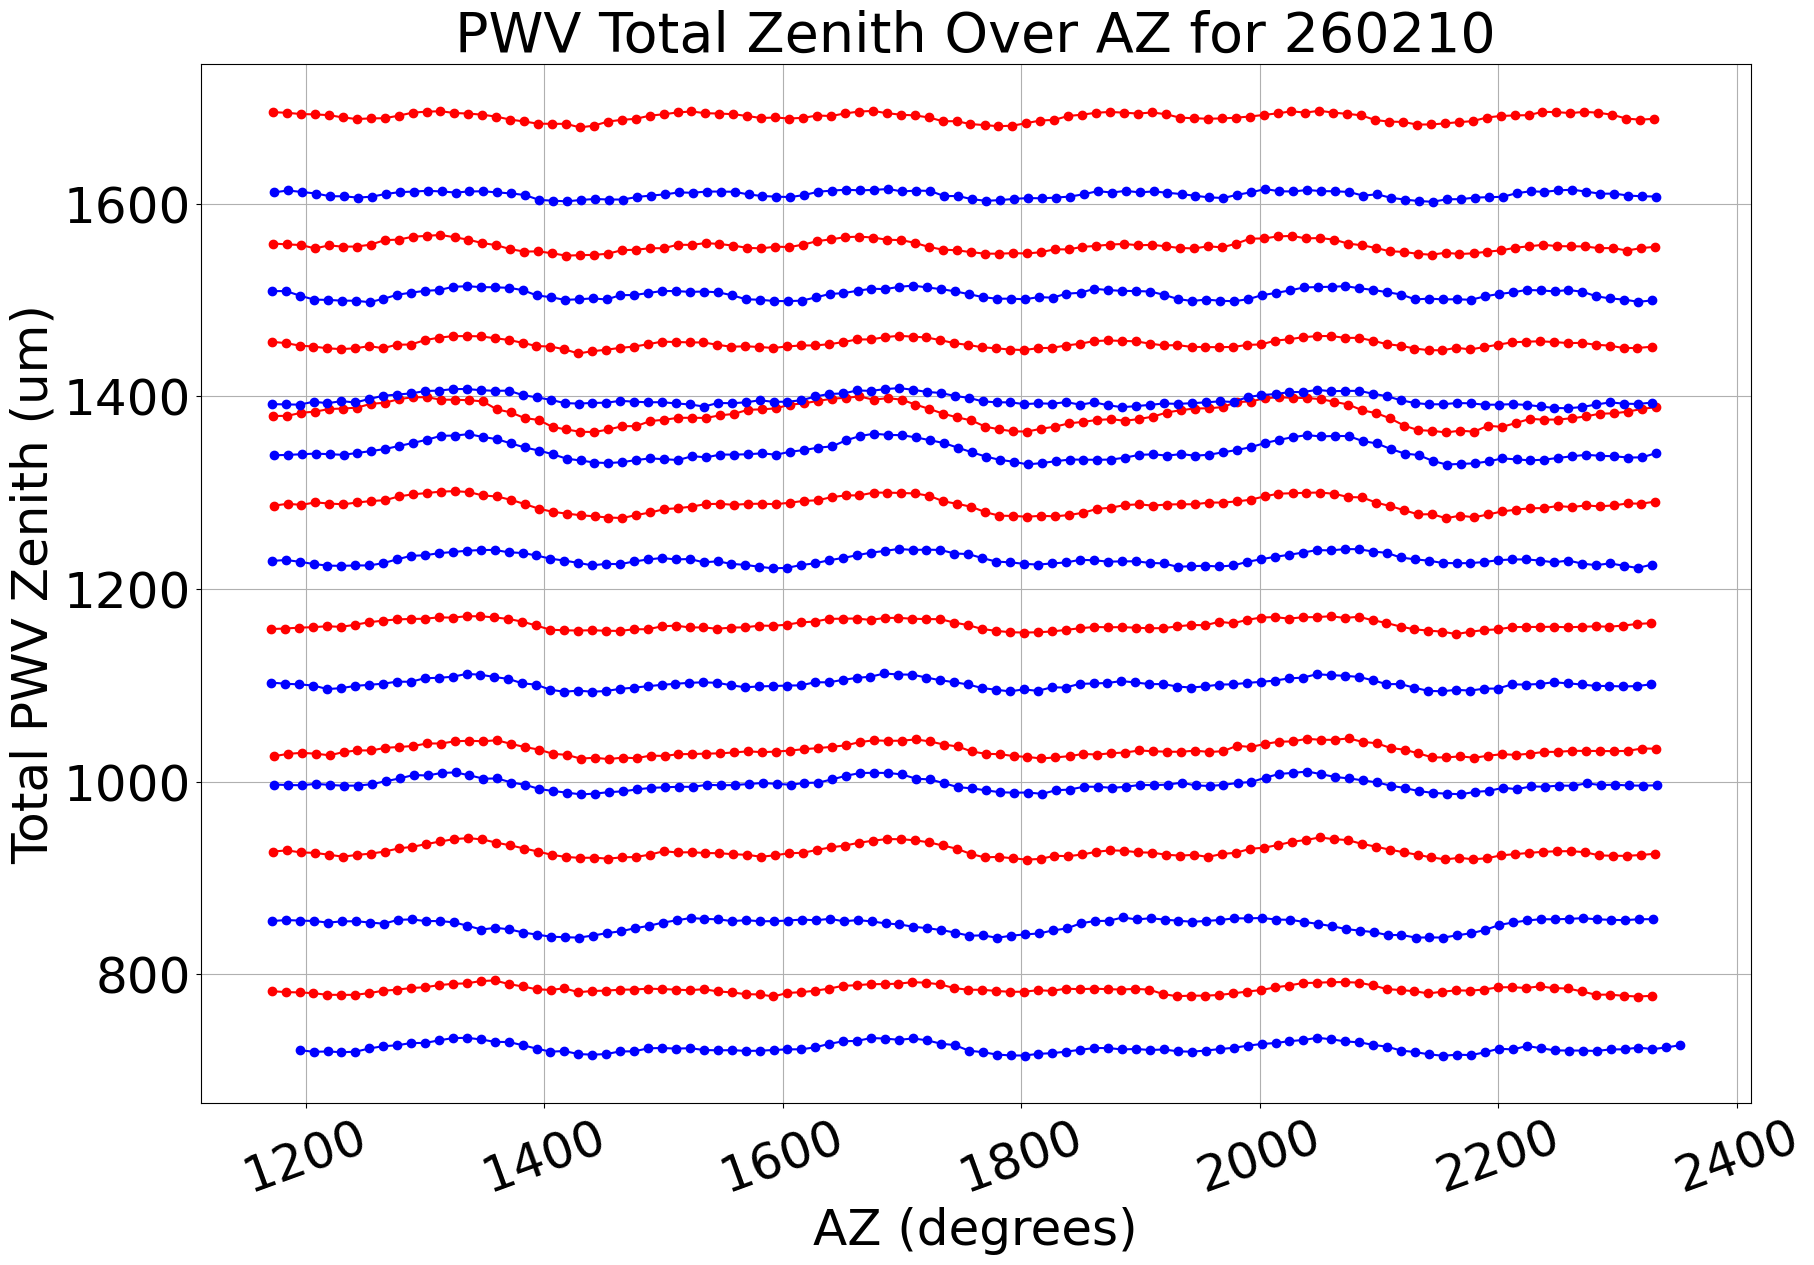

In [8]:
"""for 2026/02/10 sec data
""" 

# make plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from metpy.plots import SkewT, Hodograph
import metpy.calc as mpcalc
from metpy.units import units
from siphon.simplewebservice.wyoming import WyomingUpperAir
import os

seasons = ['260210']
files = glob.glob('2602/0210Sec/time_pwv_2602_*.csv')
TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []
for file in files:
    df = pd.read_csv(file, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})

    if df['START TIME(HHMMSS.Microsec)'][0] == '010136.217888':
        #print("Found missing time, adding it to the dataframe")
        # Create a new row as dictionary
        new_row = {
            "DATE(YYYYMMDD)": "20260210",
            "START TIME(HHMMSS.Microsec)": "010253.121565",
            "END TIME(HHMMSS.Microsec)": "010253.121565",
            "PWV TOTAL zenith": "729.18 um_pwv",
            "PWV TOTAL line-of-sight": "890.165 um_pwv",
            "Nscale_troposphere_h2o": 1.71789
        }

        # Append row
        df.loc[len(df)] = new_row

    df['TIME'] = pd.to_datetime(df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    df = df.sort_values(by='TIME') 
    TIME.extend(df['TIME'].tolist())

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

showAngle_df = pd.read_csv('2602/showAngle2602.csv')
#remove the csv header
showAngleTime = []
showAngleAZ = []
showAngleTime.extend(showAngle_df['Time'].tolist())
showAngleAZ.extend(showAngle_df['AZ'].tolist())

try:
    showAngleTime = pd.to_datetime(showAngleTime, format='%Y-%m-%d %H:%M:%S.%f')
except Exception as e:
    print(f"Error parsing showAngleTime: {e}")

# print("AZ length",len(showAngleAZ),(showAngleAZ[0]))
# print("PWV len ", len(PWV_TOTAL_zenith),type(PWV_TOTAL_zenith[0]))
# print("TIME len ", len(TIME),type(TIME[0]))
# print("showAngleTime len ", len(showAngleTime),type(showAngleTime[0]))

try:
    for i in range(len(showAngleTime)):
        if showAngleTime[i] != TIME[i]:
            print("Not matching time: ", showAngleTime[i])
except Exception as e:
    print(f"Error comparing times: {e}")


AZ_deg = [[]]
PWV_Zen = [[]]

for i in range(len(showAngleAZ)):
    if i-1 > 0:
        if showAngleAZ[i] >= showAngleAZ[i-1]:
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])
        else:
            AZ_deg.append([])
            PWV_Zen.append([])
            # print(f"length of AZ_deg {len(AZ_deg)}")
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])

colors = ['b', 'r']
offset = 0
plt.figure(figsize=(40/2, 27/2))

for i in range(len(AZ_deg)):
    # print(f"len of AZ_deg[{i}] {len(AZ_deg[i])}, len of PWV_Zen[{i}] {len(PWV_Zen[i])}")
    plt.plot(AZ_deg[i][100:200], [PWV + offset for PWV in PWV_Zen[i][100:200]], marker='o', color=colors[i % len(colors)])
    offset += 50

plt.title(f'PWV Total Zenith Over AZ for {seasons[0]}', fontsize=40)
plt.xlabel('AZ (degrees)', fontsize=36)
plt.ylabel('Total PWV Zenith (um)', fontsize=36)
plt.xticks(rotation=20, fontsize=36)
plt.yticks(fontsize=36)
plt.grid()
plt.show()
plt.close()


# plt.figure(figsize=(40/2, 27/2))
# plt.scatter(TIME, PWV_TOTAL_zenith, marker='o', linestyle='-', color='b', label='am PWV Data')
# plt.title(f'PWV Total Zenith Over Sec for {seasons[0]}', fontsize=40)
# plt.ylabel('Total PWV Zenith (um)', fontsize=36) 
# plt.xticks(rotation=30, fontsize=36)
# plt.yticks(fontsize=36)
# plt.grid()
# plt.legend(loc='upper left', fontsize=32)
# plt.savefig(f'2602/Plots/pwv_total_zenith_over_time_for{seasons[0]}.png', dpi=450)
# plt.show()
# plt.close()



Error


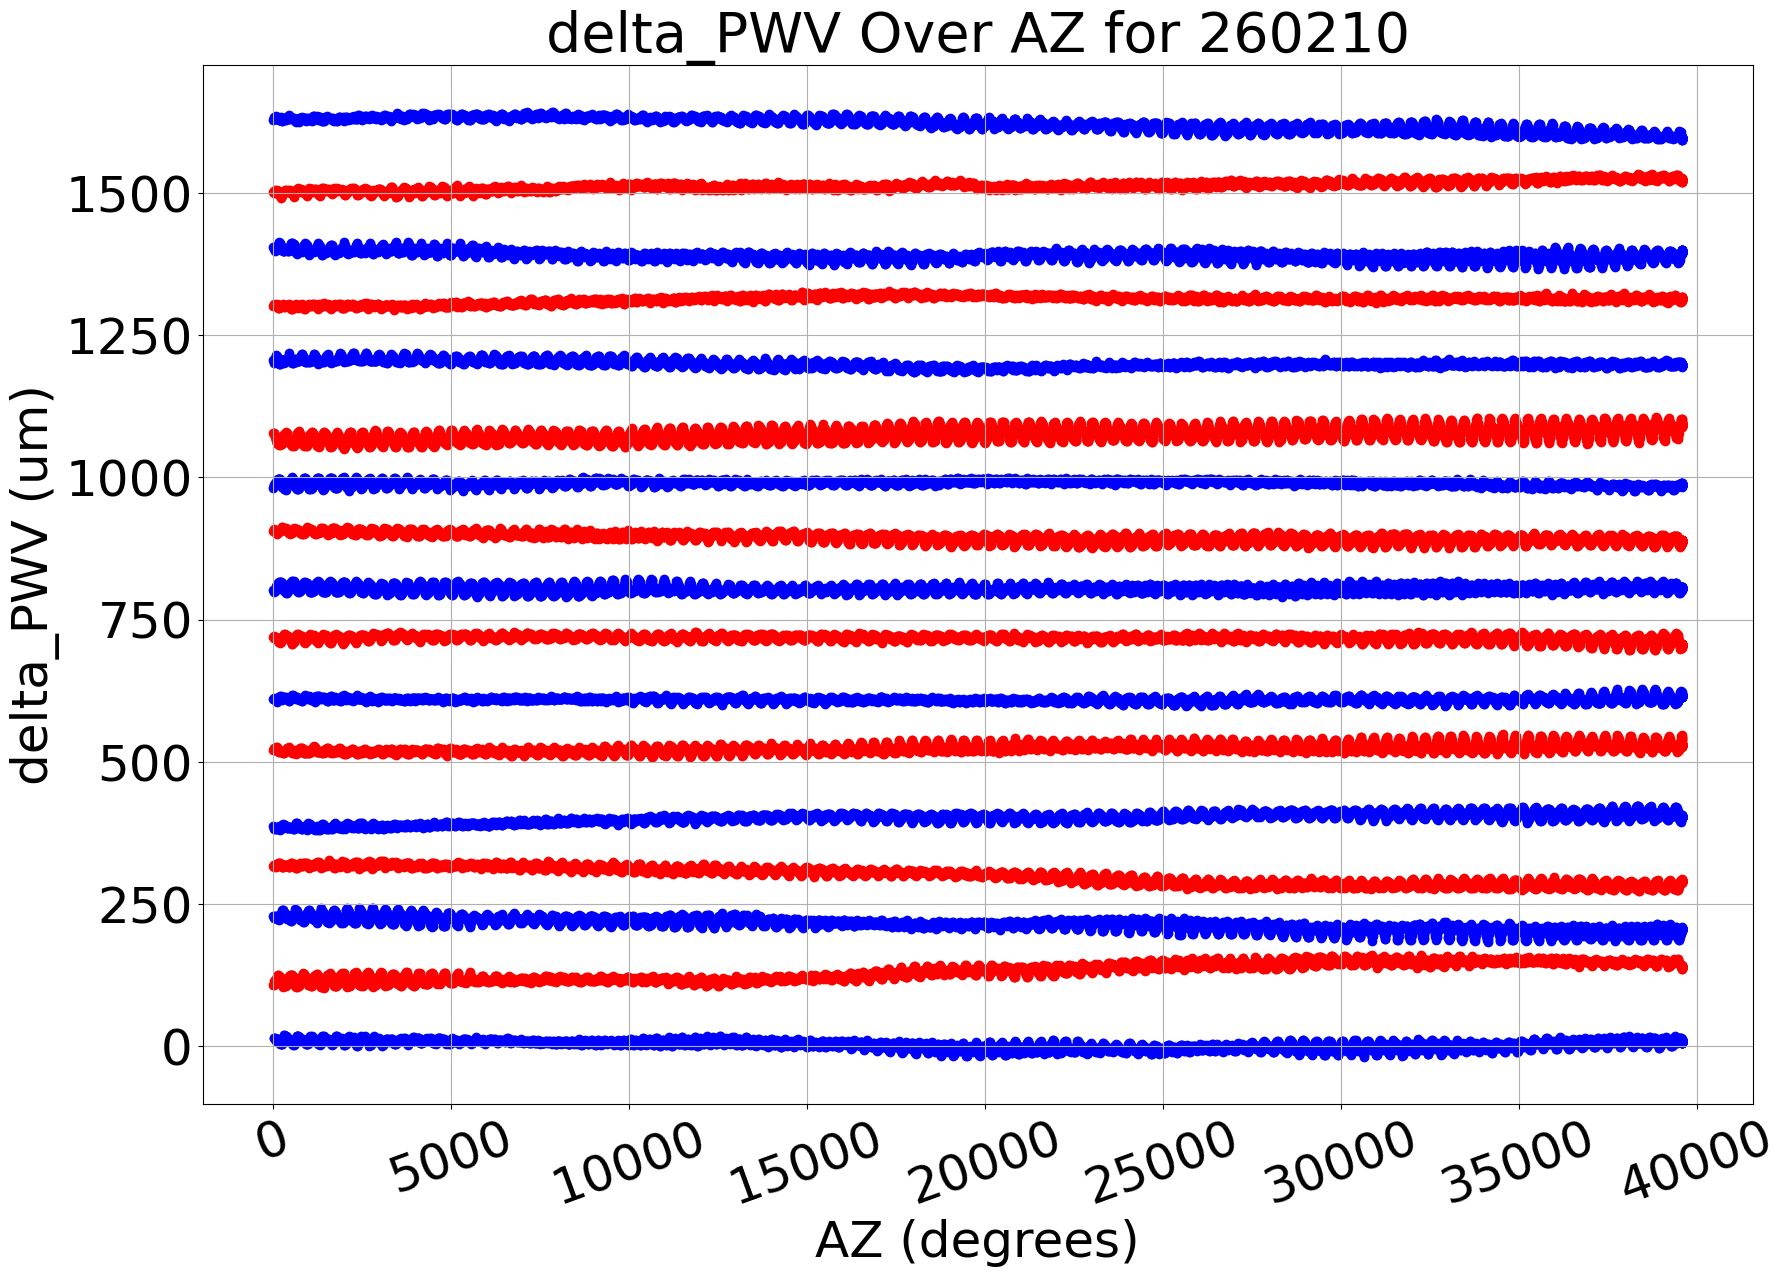

In [2]:
"""for 2026/02/10 sec data
""" 

# make plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import glob 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from metpy.plots import SkewT, Hodograph
import metpy.calc as mpcalc
from metpy.units import units
from siphon.simplewebservice.wyoming import WyomingUpperAir
import os

seasons = ['260210']
files = glob.glob('2602/0210Sec/time_pwv_2602_*.csv')
TIME = []
PWV_TOTAL_zenith = []
PWV_TOTAL_line_of_sight = []
for file in files:
    df = pd.read_csv(file, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})

    if df['START TIME(HHMMSS.Microsec)'][0] == '010136.217888':
        #print("Found missing time, adding it to the dataframe")
        # Create a new row as dictionary
        new_row = {
            "DATE(YYYYMMDD)": "20260210",
            "START TIME(HHMMSS.Microsec)": "010253.121565",
            "END TIME(HHMMSS.Microsec)": "010253.121565",
            "PWV TOTAL zenith": "729.18 um_pwv",
            "PWV TOTAL line-of-sight": "890.165 um_pwv",
            "Nscale_troposphere_h2o": 1.71789
        }

        # Append row
        df.loc[len(df)] = new_row

    df['TIME'] = pd.to_datetime(df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    df = df.sort_values(by='TIME') 
    TIME.extend(df['TIME'].tolist())

    df['PWV TOTAL zenith'] = df['PWV TOTAL zenith'].str.replace(' um_pwv', '').astype(float)
    df['PWV TOTAL line-of-sight'] = df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '').astype(float)
    PWV_TOTAL_zenith.extend(df['PWV TOTAL zenith'].tolist())
    PWV_TOTAL_line_of_sight.extend(df['PWV TOTAL line-of-sight'].tolist())

showAngle_df = pd.read_csv('2602/showAngle2602.csv')
#remove the csv header
showAngleTime = []
showAngleAZ = []
showAngleTime.extend(showAngle_df['Time'].tolist())
showAngleAZ.extend(showAngle_df['AZ'].tolist())

try:
    showAngleTime = pd.to_datetime(showAngleTime, format='%Y-%m-%d %H:%M:%S.%f')
except Exception as e:
    print(f"Error parsing showAngleTime: {e}")

# print("AZ length",len(showAngleAZ),(showAngleAZ[0]))
# print("PWV len ", len(PWV_TOTAL_zenith),type(PWV_TOTAL_zenith[0]))
# print("TIME len ", len(TIME),type(TIME[0]))
# print("showAngleTime len ", len(showAngleTime),type(showAngleTime[0]))

try:
    for i in range(len(showAngleTime)):
        if showAngleTime[i] != TIME[i]:
            print("Not matching time: ", showAngleTime[i])
except Exception as e:
    print(f"Error comparing times: {e}")


AZ_deg = [[]]
PWV_Zen = [[]]

for i in range(len(showAngleAZ)):
    if i-1 > 0:
        if showAngleAZ[i] >= showAngleAZ[i-1]:
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])
        else:
            AZ_deg.append([])
            PWV_Zen.append([])
            # print(f"length of AZ_deg {len(AZ_deg)}")
            AZ_deg[len(AZ_deg)-1].append(showAngleAZ[i])
            PWV_Zen[len(PWV_Zen)-1].append(PWV_TOTAL_zenith[i])

delta_PWV_AZ_previous = [[]]
for i in range(len(PWV_Zen)):
    if i+1 < len(PWV_Zen) and len(PWV_Zen[i+1]) > 0:
        for j in range(len(PWV_Zen[0])-1): # give a constant length 
            if j < len(PWV_Zen[i+1]):
                delta_PWV_AZ_previous[i].append(PWV_Zen[i+1][j] - PWV_Zen[i][j])
        delta_PWV_AZ_previous.append([])

colors = ['b', 'r']
offset = 0
plt.figure(figsize=(40/2, 27/2))

# print("AZ_deg length", len(AZ_deg))
# print("delta_PWV_AZ_previous length", len(delta_PWV_AZ_previous))
# print("len for 1st [] of AZ",len(AZ_deg[0]))
# print("len for 1st delta PWV", len(delta_PWV_AZ_previous[0]))

for i in range(len(delta_PWV_AZ_previous)):
    if len(delta_PWV_AZ_previous[i]) > 0:
        #print(f"work for i={i}, len of delta_PWV_AZ_previous[i] {len(delta_PWV_AZ_previous[i])}, len of AZ_deg[i] {len(AZ_deg[i])}")
        plt.scatter(AZ_deg[i][:len(PWV_Zen[0])-1], [offset + delta for delta in delta_PWV_AZ_previous[i]], marker='o', color=colors[i % len(colors)])
        offset += 100
    else:
        print("Error")

plt.title(f'delta_PWV Over AZ for {seasons[0]}', fontsize=40)
plt.xlabel('AZ (degrees)', fontsize=36)
plt.ylabel('delta_PWV (um)', fontsize=36)
plt.xticks(rotation=20, fontsize=36)
plt.yticks(fontsize=36)
plt.grid()
plt.show()
plt.close()

